# TP7: Diffraction de rayons X par une surface cristalline 

## Etude numérique

# 1

In [133]:
"""Importation des modules"""
import numpy as np 
import matplotlib.pyplot as plt
from scipy.fftpack import *

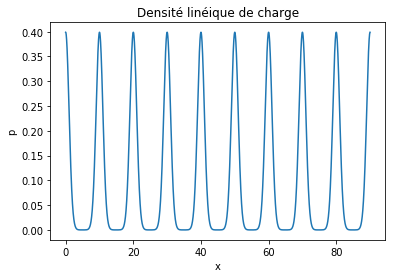

In [142]:
def densite(x,n,a,sigma):
    S=0
    for j in range(n):
        S+=np.exp(-(x-j*a)**2 / (2*sigma**2))
    return S/(sigma*(2*np.pi)**0.5)


a=10
n=10
sigma=1

X=np.arange(0,(n-1)*a,0.01)
P=densite(X,n,a,sigma)

plt.plot(X,P)
plt.title('Densité linéique de charge')
plt.xlabel('x')
plt.ylabel('p')

plt.show()

# 2

In [145]:
def DSP1D(X,f):
    TDF=fft(f(X))
    TFD_shift=np.abs(fftshift(TDF))**2
    q=fftshift(fftfreq(len(X), X[1]-X[0]))
    TFD_shift=TFD_shift/np.max(TFD_shift)
    return q,TFD_shift

# 3

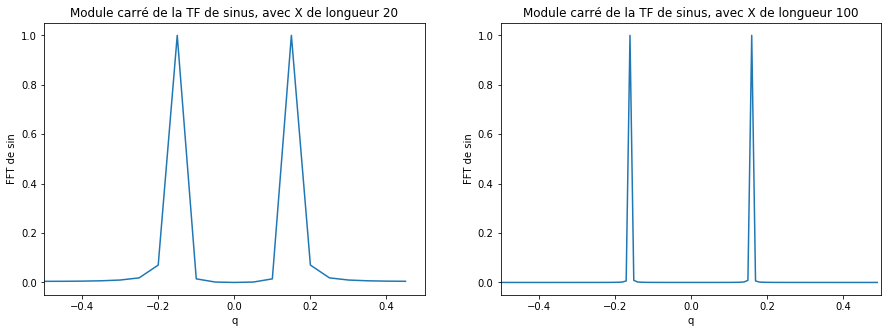

In [159]:
# Test pour la fonction sinus

Xtest1=np.arange(0,20,1)
Xtest2=np.arange(0,100,1)


plt.subplots(figsize=(15, 5)) 


plt.subplot(1, 2, 1) 
plt.plot(DSP1D(Xtest1,np.sin)[0], DSP1D(Xtest1,np.sin)[1])
plt.title("Module carré de la TF de sinus, avec X de longueur 20")
plt.xlabel('q')
plt.ylabel('FFT de sin')
plt.xlim(-0.5,0.5)


plt.subplot(1, 2, 2) 
plt.plot(DSP1D(Xtest2,np.sin)[0], DSP1D(Xtest2,np.sin)[1])
plt.title("Module carré de la TF de sinus, avec X de longueur 100")
plt.xlabel('q')
plt.ylabel('FFT de sin')
plt.xlim(-0.5,0.5)

plt.show()

La résolution du vecteur de diffusion q est $\frac{q_{max}}{longueur(x)}$ avec $q_{max}=\frac{1}{résolution(x)}$.

# 4

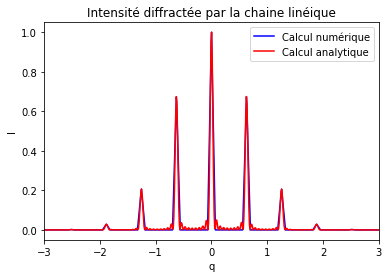

In [162]:
a=10
n=10
sigma=1

X=np.arange(0,(n-1)*a,0.01)
q=fftshift(fftfreq(len(X), X[1]-X[0]))

def qsanszero(q): #axe des abcisses utilisé pour tracer l'intensité I analytique
    resq=np.max(q)/len(q)
    return q+0.5*resq*np.ones(len(q))

def I(q,n,a,sigma):
    I2=np.exp(-(q*sigma)**2)*(np.sin(q*n*a/2)/np.sin(q*a/2))**2
    return I2/np.max(I2) #normalisation de l'intensité

def rho(X): #la densité devient une fonction rho d'une seule variable X
    return densite(X,n,a,sigma)

plt.plot(2*np.pi*DSP1D(X,rho)[0], DSP1D(X,rho)[1], label='Calcul numérique', color='b')
plt.plot(qsanszero(q),I(qsanszero(q),n,a,sigma), label='Calcul analytique', color='r')
plt.title("Intensité diffractée par la chaine linéique")
plt.xlabel("q")
plt.ylabel("I")
plt.xlim(-3,3)
plt.legend()

plt.show()

## Intensité 2D diffusée par un unique atome

# 5

In [163]:
def DSP2D(X,Y,f):
    TDF=fft2(f) #utilisation de fft2 
    TFD_shift=np.abs(fftshift(TDF))**2
    qx=fftshift(fftfreq(len(X), X[1]-X[0]))
    qy=fftshift(fftfreq(len(Y), Y[1]-Y[0]))
    TFD_shift=TFD_shift/np.max(TFD_shift)
    return qx, qy,TFD_shift 

# 6

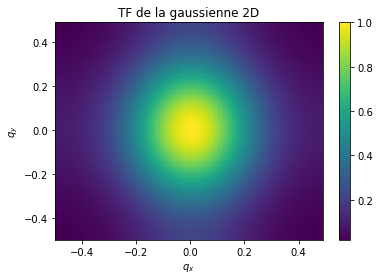

In [170]:
#Test avec une gaussienne centrée
sigmax=1
sigmay=1

def gaussienne(x,y): #centrée en (0,0)
    return 1/(sigmax*sigmay*(2*np.pi)**0.5)*np.exp(-(0.5*(x/sigmax)**2+(y/sigmay)**2))


a=10
n=10
X=np.arange(0,(n-1)*a,1)
Y=np.arange(0,(n-1)*a,1)

Xx,Yy=np.meshgrid(X,Y)
qx,qy,Z=DSP2D(X,Y,gaussienne(Xx,Yy))
plt.pcolormesh(qx,qy,Z)
plt.title("TF de la gaussienne 2D")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")
plt.colorbar()

plt.show()

# 7

In [174]:
def reseau1(m,a):
    M=[]
    for n in range(m):
        for p in range(m):
            M.append([(0.25+n)*a,(0.25+p)*a]) #l'origine a été décalée de 0.25a
    return np.array(M)


# 8

In [175]:
def densite_atome(x,y,xat,yat,sigma): # avec xat et yat des scalaires
    return 1/(sigma**2*(2*np.pi)**0.5)*np.exp(-(0.5/sigma**2*((x-xat)**2+(y-yat)**2)))

def reseau_carre(x,y,xat,yat,sigma):# avec xat et yat les listes des coordonées des atomes
    S=0
    for k in range(len(xat)):
        S+=densite_atome(x,y,xat[k],yat[k],sigma)
    return S


# 9

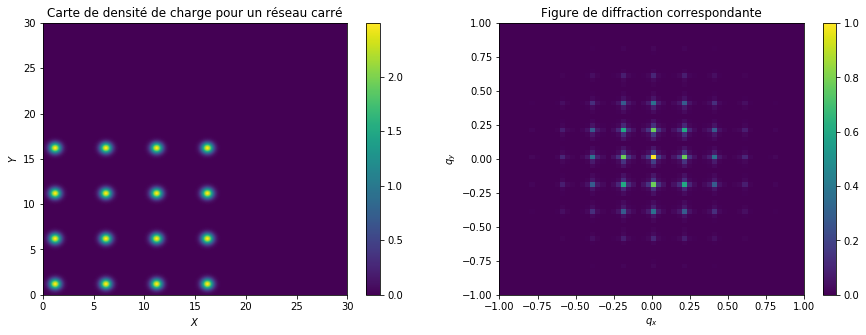

In [185]:
#On prend l'Angström comme l'unité
A=1
X=np.arange(0,30*A,0.01*A)
Y=np.arange(0,30*A,0.01*A)

xat, yat = reseau1(4, 5)[:, 0], reseau1(4, 5)[:, 1]

Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)


plt.subplots(figsize=(15, 5)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(Xx,Yy,Z)
plt.colorbar()
plt.title("Carte de densité de charge pour un réseau carré")
plt.xlabel("$X$")
plt.ylabel("$Y$")

plt.subplot(1, 2, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction correspondante")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

# 10

Le réseau cristallin a un paramètre de maille a=5$Angström$. Le réseau réciproque a donc un paramètre de maille de $\frac{1}{5}=0.2Angström^{-1}$. C'est ce qu'on peut observer sur la figure de diffraction.
On peut améliorer la résolution en augmentant les valeurs maximales prises par X et Y.

sigma=0.4 Angström


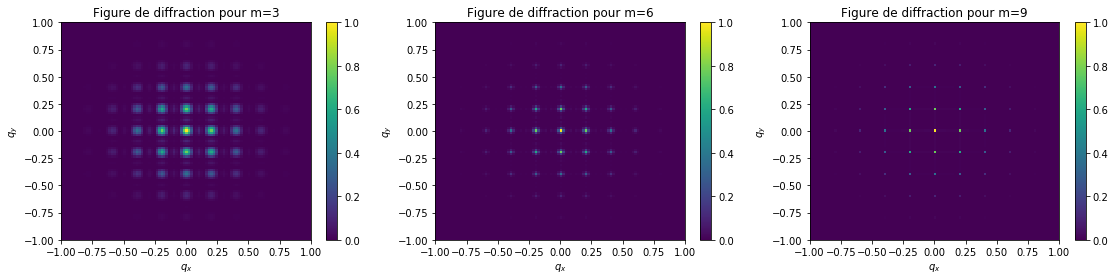

In [197]:
"""Influence de m sur la figure de diffraction"""

X=np.arange(0,50*A,0.05*A)
Y=np.arange(0,50*A,0.05*A)

print("sigma=0.4 Angström")

plt.subplots(figsize=(19, 4)) 

"""m=3 et sigma=0.4""" 

xat, yat = reseau1(3, 5)[:, 0], reseau1(3, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 1)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=3")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.4""" 

xat, yat = reseau1(6, 5)[:, 0], reseau1(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=6")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=9 et sigma=0.4""" 

xat, yat = reseau1(9, 5)[:, 0], reseau1(9, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 3)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=9")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

On observe que les taches de diffraction se resserrent lorsque le nombre d'atomes augmentent. 

m=6, soit 36 atomes


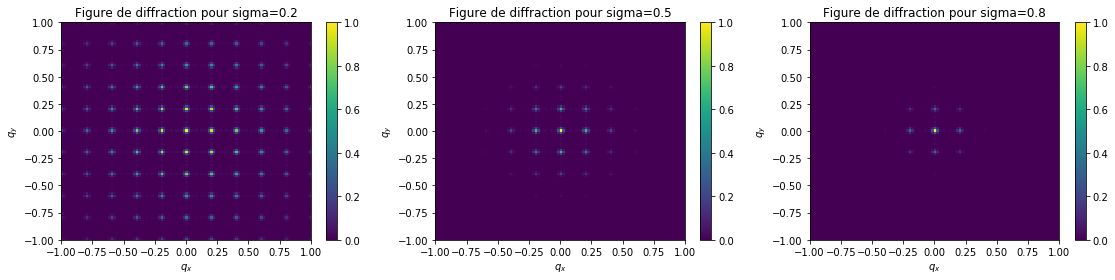

In [199]:
"""Influence de sigma sur la figure de diffraction"""

X=np.arange(0,50*A,0.05*A)
Y=np.arange(0,50*A,0.05*A)

print("m=6, soit 36 atomes")

plt.subplots(figsize=(19, 4)) 

"""m=6 et sigma=0.2""" 

xat, yat = reseau1(6, 5)[:, 0], reseau1(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.2*A)

plt.subplot(1, 3, 1)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.2")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.5""" 

xat, yat = reseau1(6, 5)[:, 0], reseau1(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.5*A)

plt.subplot(1, 3, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.5")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.8""" 

xat, yat = reseau1(6, 5)[:, 0], reseau1(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.8*A)

plt.subplot(1, 3, 3)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.8")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

Plus les charges restent localisées autour des atomes (sigma petit), plus la figure de diffraction est étalée.
A l'inverse lorsque les charges sont délocalisées autour des atomes, la figure de diffraction disparaît presque.

# 11

m=4, soit 16 atomes


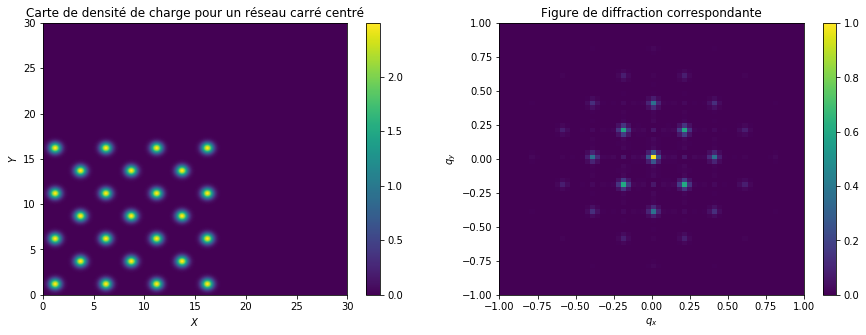

In [202]:
X=np.arange(0,30*A,0.01*A)
Y=np.arange(0,30*A,0.01*A)
print("m=4, soit 16 atomes")

def reseau2(m,a): # maille de type "carré centré"
    M=[]
    for n in range(m):
        for p in range(m):
            M.append([(0.25+n)*a,(0.25+p)*a])
    for n in range(m-1):
        for p in range(m-1):
            M.append([(0.25+n+0.5)*a,(0.25+p+0.5)*a])
    return np.array(M)

xat, yat = reseau2(4, 5)[:, 0], reseau2(4, 5)[:, 1]

Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplots(figsize=(15, 5)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(Xx,Yy,Z)
plt.colorbar()
plt.title("Carte de densité de charge pour un réseau carré centré")
plt.xlabel("$X$")
plt.ylabel("$Y$")

plt.subplot(1, 2, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction correspondante")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

Figure de diffraction d'un réseau carré centré
sigma=0.4 Angström


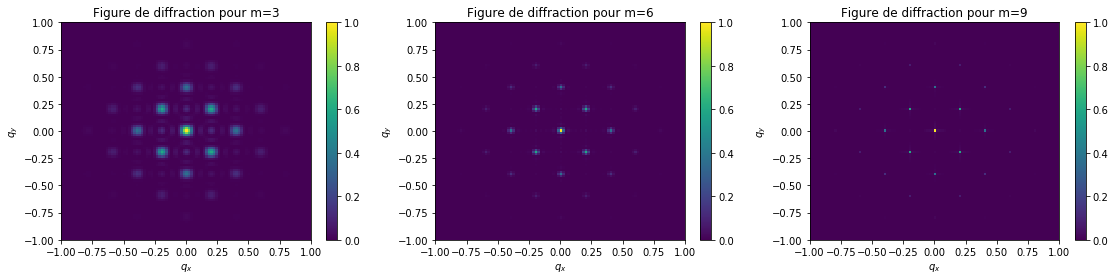

In [203]:
"""Influence de m sur la figure de diffraction"""

print("Figure de diffraction d'un réseau carré centré")


X=np.arange(0,50*A,0.05*A)
Y=np.arange(0,50*A,0.05*A)

print("sigma=0.4 Angström")

plt.subplots(figsize=(19, 4)) 

"""m=3 et sigma=0.4""" 

xat, yat = reseau2(3, 5)[:, 0], reseau2(3, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 1)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=3")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.4""" 

xat, yat = reseau2(6, 5)[:, 0], reseau2(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=6")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=9 et sigma=0.4""" 

xat, yat = reseau2(9, 5)[:, 0], reseau2(9, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplot(1, 3, 3)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour m=9")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

Figure de diffraction d'un réseau carré centré
m=6, soit 36 atomes


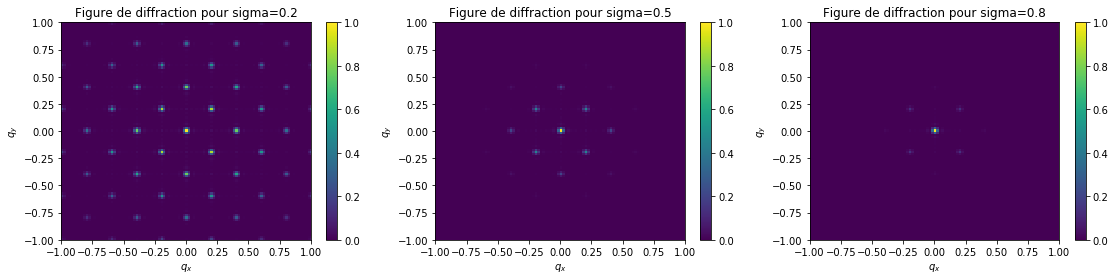

In [205]:
"""Influence de sigma sur la figure de diffraction"""
print("Figure de diffraction d'un réseau carré centré")


X=np.arange(0,50*A,0.05*A)
Y=np.arange(0,50*A,0.05*A)

print("m=6, soit 36 atomes")

plt.subplots(figsize=(19, 4)) 

"""m=6 et sigma=0.2""" 

xat, yat = reseau2(6, 5)[:, 0], reseau2(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.2*A)

plt.subplot(1, 3, 1)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.2")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.5""" 

xat, yat = reseau2(6, 5)[:, 0], reseau2(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.5*A)

plt.subplot(1, 3, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.5")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""m=6 et sigma=0.8""" 

xat, yat = reseau2(6, 5)[:, 0], reseau2(6, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.8*A)

plt.subplot(1, 3, 3)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction pour sigma=0.8")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

L'influence des paramètres m (nombre d'atomes) et sigma (étendue spatiale des charges électriques autour de leur atome respectif) est la même pour le réseau carré centré que pour le réseau carré: les tâches de diffraction deviennent des points lorsque m augmente, et la figure s'estompe lorsque sigma augmente. 

# 12

m=4, soit 16 atomes


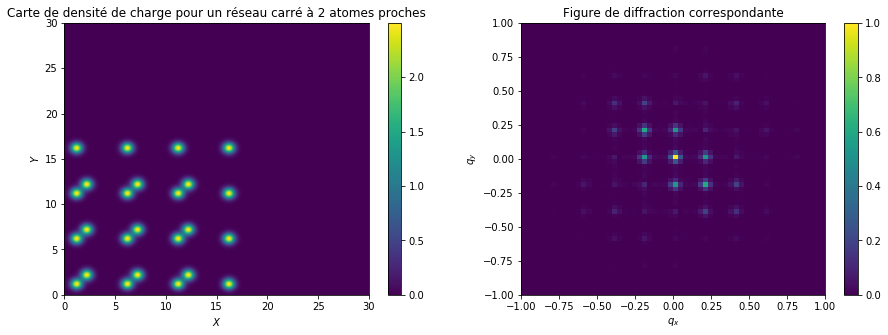

In [206]:
"""Réseau carré pour lequel la maille a 2 atomes proches"""

X=np.arange(0,30*A,0.01*A)
Y=np.arange(0,30*A,0.01*A)
print("m=4, soit 16 atomes")

def reseau3(m,a):
    M=[]
    for n in range(m):
        for p in range(m):
            M.append([(0.25+n)*a,(0.25+p)*a])
    for n in range(m-1):
        for p in range(m-1):
            M.append([(0.25+n+0.2)*a,(0.25+p+0.2)*a])
    return np.array(M)

xat, yat = reseau3(4, 5)[:, 0], reseau3(4, 5)[:, 1]

Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.4*A)

plt.subplots(figsize=(15, 5)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(Xx,Yy,Z)
plt.colorbar()
plt.title("Carte de densité de charge pour un réseau carré à 2 atomes proches")
plt.xlabel("$X$")
plt.ylabel("$Y$")

plt.subplot(1, 2, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction correspondante")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

Il est intéressant de comparer les figures de diffraction obtenues avec les 3 réseaux, pour un nombre d'atomes et un sigma fixé:

sigma=0.3Angström et m=8


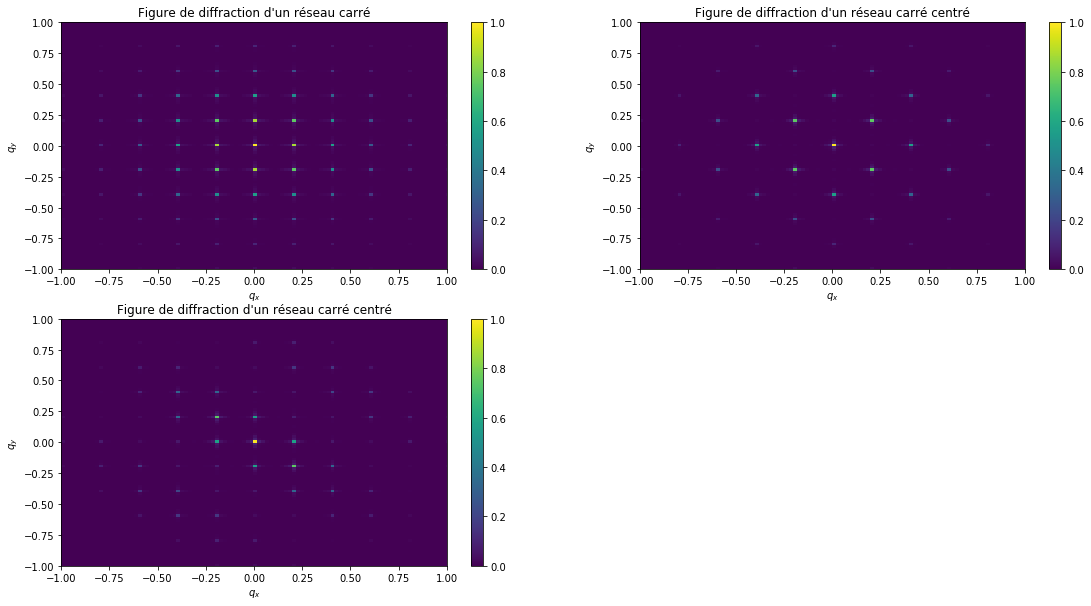

In [209]:
print("sigma=0.3Angström et m=8")

X=np.arange(0,50*A,0.05*A)
Y=np.arange(0,50*A,0.05*A)

plt.subplots(figsize=(19, 10)) 

"""Réseau carré""" 

xat, yat = reseau1(8, 5)[:, 0], reseau1(8, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.3*A)

plt.subplot(2, 2, 1)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction d'un réseau carré")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""Réseau carré centré""" 

xat, yat = reseau2(8, 5)[:, 0], reseau2(8, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.3*A)

plt.subplot(2, 2, 2)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction d'un réseau carré centré")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

"""Réseau carré centré à 2 atomes""" 

xat, yat = reseau3(8, 5)[:, 0], reseau3(8, 5)[:, 1]
Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.3*A)

plt.subplot(2, 2, 3)
qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction d'un réseau carré centré à 2 atomes")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()

On observe entre le réseau carré et celui carré centré que l'ajout de noeuds au réseau a fait diminuer le paramètre de maille spatial. Les noeuds du réseau réciproque sont donc plus éloignés les unes des autres.
De plus, sur la figure de diffraction du réseau carré centré à 2 atomes, la périodicité dûe à l'ajout d'un 2ème atome selon la diagonale se retrouve sur le réseau réciproque. L'intensité lumineuse fait une gaussienne le long de l'axe de la diagonale.

# 13

Sur la figure 5, on peut mesurer à la règle la distance entre 2 noeuds successifs du réseau réciproque : ils sont distants de 1cm sur l'image, soit q=1.17 $Angström^{-1}$ d'après l'échelle. On peut en déduire le paramètre de maile du Silicium en surface: $a = \frac{2\pi}{q} = 5.37 Angström$. On trouve un résultat cohérent avec les 5.43$Angström$ annoncés.

m=8 soit 64 atomes, sigma=0.2 et a=5.43Angström


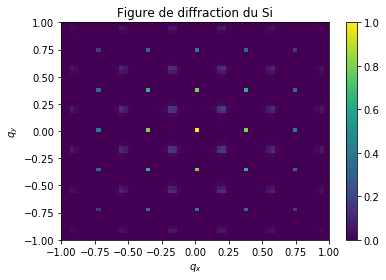

In [212]:
"""Paramètre de maille : a=5.43Angström"""
X=np.arange(0,30*A,0.03*A)
Y=np.arange(0,30*A,0.03*A)
print("m=8 soit 64 atomes, sigma=0.2 et a=5.43Angström")


xat, yat = reseau2(8, 5.43)[:, 0], reseau2(8, 5.43)[:, 1]

Xx,Yy=np.meshgrid(X,Y)
Z=reseau_carre(Xx,Yy,xat,yat,0.2*A)

qx,qy,Z2=DSP2D(X,Y,Z)
plt.pcolormesh(qx,qy,Z2)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.colorbar()
plt.title("Figure de diffraction du Si")
plt.xlabel("$q_{x}$")
plt.ylabel("$q_{y}$")

plt.show()